 # Step 1: Environment Setup & Installations

In [9]:
# Install required libraries
!pip install --quiet --no-warn-script-location ultralytics opencv-python-headless numpy torch torchvision fastdtw transformers lapx

import sys
import os
import json
from pathlib import Path
import cv2
import numpy as np
import torch
from ultralytics import YOLO
from transformers import CLIPTokenizer, CLIPTextModel
from tqdm.auto import tqdm
import shutil
from google.colab import drive
import subprocess
import datetime
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Add GLA-GCN to the Python path so we can import their models later
if "/content/GLA-GCN" not in sys.path:
    sys.path.append("/content/GLA-GCN")

# Clone the 3D lifting repositories
# !rm -rf /content/GLA-GCN
!git clone https://github.com/bruceyo/GLA-GCN.git

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# ---------------------------------------------------------
# UPDATE THIS PATH TO YOUR ACTUAL SHARED DRIVE FOLDER
# ---------------------------------------------------------
BASE_PATH = Path("/content/drive/MyDrive/ITCS 4152 5010")

# Setup directory structure variables
input_dir = BASE_PATH / "Data"
output_video_dir = BASE_PATH / "outputs/annotated_videos"
output_keypoint_dir = BASE_PATH / "outputs/keypoints"
output_standardized_dir = BASE_PATH / "outputs/standardized_2d"
output_glagcn_dir = BASE_PATH / "outputs/poses_3d/glagcn"

if not input_dir.exists():
    print(f"ERROR: Cannot find {input_dir}. Check your BASE_PATH.")

# Create directories if they don't exist
# output_video_dir.mkdir(parents=True, exist_ok=True)
# output_keypoint_dir.mkdir(parents=True, exist_ok=True)
# output_standardized_dir.mkdir(parents=True, exist_ok=True)
# output_glagcn_dir.mkdir(parents=True, exist_ok=True)

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Compute Device Active: {device}")
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print("CRITICAL ERROR: PyTorch cannot see the GPU!")

fatal: destination path 'GLA-GCN' already exists and is not an empty directory.
Mounted at /content/drive
Compute Device Active: cuda
PyTorch Version: 2.10.0+cu128
GPU Device: Tesla T4


 # Step 2: YOLOv8 2D Pose Extraction (Sequential Tracking)

In [23]:
# 1. Configuration
RELEVANT_FOLDERS = ["correct", "incorrect"]
yolo_model = YOLO("yolov8m-pose.pt")
yolo_model.to('cuda')
VIDEO_EXTENSIONS = {".mp4", ".mov", ".avi", ".mkv"}

COCO_SKELETON = [
    (0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8),
    (8, 10), (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16)
]

def log(msg):
    print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] {msg}")


def get_video_fps(video_path: Path) -> float:
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return float(fps) if fps and fps > 0 else 30.0

def compute_hard_attention_scores(xyxy: np.ndarray, confs: np.ndarray, width: float, height: float) -> np.ndarray:
    """Upgraded with Center-Weighted Spatial Scoring to ignore the ceiling"""
    areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])

    center_x, center_y = width / 2.0, height / 2.0
    max_dist = np.sqrt(center_x**2 + center_y**2)

    box_centers_x = (xyxy[:, 0] + xyxy[:, 2]) / 2.0
    box_centers_y = (xyxy[:, 1] + xyxy[:, 3]) / 2.0
    distances = np.sqrt((box_centers_x - center_x)**2 + (box_centers_y - center_y)**2)

    proximity_scores = 1.0 - (distances / max_dist)
    return (areas * 0.4) * (confs * 0.2) * (proximity_scores * 0.4)

def select_primary_index(scores: np.ndarray) -> int | None:
    """Stateless selection: Just pick the highest scoring box in the current frame"""
    if scores.size == 0:
        return None
    return int(np.argmax(scores))

def draw_primary_subject(frame: np.ndarray, box: np.ndarray, keypoints_xy: np.ndarray, keypoints_conf: np.ndarray, min_kpt_conf: float) -> None:
    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(frame, (x1, y1), (x2, y2), (60, 180, 255), 2)
    cv2.putText(frame, "Primary Subject", (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (60, 180, 255), 2, cv2.LINE_AA)

    for i, (x, y) in enumerate(keypoints_xy):
        if keypoints_conf[i] < min_kpt_conf: continue
        cv2.circle(frame, (int(x), int(y)), 4, (0, 220, 255), -1)

    for a, b in COCO_SKELETON:
        if keypoints_conf[a] < min_kpt_conf or keypoints_conf[b] < min_kpt_conf: continue
        cv2.line(frame, (int(keypoints_xy[a][0]), int(keypoints_xy[a][1])), (int(keypoints_xy[b][0]), int(keypoints_xy[b][1])), (0, 255, 80), 2)

def process_video(model: YOLO, optimized_video_path: Path, output_video_path: Path, output_keypoint_path: Path, conf: float, kpt_conf: float) -> None:
    all_frames: list[dict] = []
    frame_idx = 0
    fps = get_video_fps(optimized_video_path)
    writer = None

    # THE FIX: Changed .track() to .predict() to kill the hallucinating tracker
    results_stream = model.predict(
        source=str(optimized_video_path),
        stream=True,
        conf=conf,
        imgsz=1280,
        half=True,
        verbose=False,
        device="cuda:0"
    )

    for result in results_stream:
        frame = result.orig_img.copy()
        height, width = frame.shape[:2]

        if writer is None:
            writer = cv2.VideoWriter(str(output_video_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

        frame_data = {"frame": frame_idx, "people": []}
        primary_box, primary_keypoints_xy, primary_keypoints_conf = None, None, None

        if result.boxes is not None and len(result.boxes) > 0:
            xyxy = result.boxes.xyxy.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()

            # Center-Weighted Spatial Scoring
            scores = compute_hard_attention_scores(xyxy, confs, width, height)

            # Pure stateless selection
            primary_index = select_primary_index(scores)

            if primary_index is not None and result.keypoints is not None:
                primary_box = xyxy[primary_index]
                primary_keypoints_xy = result.keypoints.xy[primary_index].cpu().numpy()
                primary_keypoints_conf = result.keypoints.conf[primary_index].cpu().numpy() if result.keypoints.conf is not None else np.ones(primary_keypoints_xy.shape[0], dtype=float)

        if primary_box is not None and primary_keypoints_xy is not None and primary_keypoints_conf is not None:
            draw_primary_subject(frame, primary_box, primary_keypoints_xy, primary_keypoints_conf, kpt_conf)

            person_data = {"person_id": 0, "keypoints": []}
            for joint_idx in range(len(primary_keypoints_xy)):
                person_data["keypoints"].append({
                    "joint_id": joint_idx,
                    "x": float(primary_keypoints_xy[joint_idx][0]),
                    "y": float(primary_keypoints_xy[joint_idx][1]),
                    "confidence": float(primary_keypoints_conf[joint_idx])
                })
            frame_data["people"].append(person_data)

        if writer is not None: writer.write(frame)
        all_frames.append(frame_data)
        frame_idx += 1
        if frame_idx % 100 == 0: print(f"    > Progress: {frame_idx} frames processed...")

    if writer is not None: writer.release()
    with output_keypoint_path.open("w", encoding="utf-8") as f:
        json.dump(all_frames, f, indent=2)

# --- The Main Batch Loop ---

log(f"Scanning directory: {input_dir}")
video_files = [p for p in input_dir.rglob("*") if p.suffix.lower() in VIDEO_EXTENSIONS and p.parent.name in RELEVANT_FOLDERS]

# JUST FOR TESTING: Process only the first file
video_files = [video_files[-1]]

if not video_files:
    log(f"ERROR: No videos found in folders {RELEVANT_FOLDERS}.")
else:
    log(f"Found {len(video_files)} videos. Starting pipeline...")
    output_video_dir.mkdir(parents=True, exist_ok=True) # Ensure video output dir exists

    for video_path in tqdm(video_files, desc="Batch Progress"):
        label = video_path.parent.name.lower()
        stem = f"{label}__{video_path.stem}"
        output_keypoint_path = output_keypoint_dir / f"{stem}_keypoints.json"
        output_video_path = output_video_dir / f"{stem}_annotated.mp4"

        # Checkpoint skip logic
        # if output_keypoint_path.exists(): continue

        log(f"--- PROCESSING: {stem} ---")
        local_video_path = f"/content/temp_{video_path.name}"
        optimized_video_path = f"/content/optimized_{video_path.stem}.mp4"

        shutil.copy(video_path, local_video_path)

        try:
            subprocess.run([
                "ffmpeg", "-y", "-i", local_video_path,
                "-vf", "scale=-2:720", "-r", "15", "-c:v", "libx264",
                "-preset", "ultrafast", "-an", optimized_video_path
            ], check=True, capture_output=True, text=True, timeout=300)
        except Exception as e:
            log(f"  !! FFMPEG FAILED: {stem}")
            if os.path.exists(local_video_path): os.remove(local_video_path)
            continue

        log("  Step 3/4: Tracking & Writing Annotated Video...")
        process_video(
            model=yolo_model,
            optimized_video_path=Path(optimized_video_path),
            output_video_path=output_video_path,
            output_keypoint_path=output_keypoint_path,
            conf=0.4,       # Detection confidence
            kpt_conf=0.4    # Keypoint rendering confidence
        )

        log("  Step 4/4: Finished. Cleaning up local temp files.")
        os.remove(local_video_path)
        os.remove(optimized_video_path)


[00:15:47] Scanning directory: /content/drive/MyDrive/ITCS 4152 5010/Data
[00:15:47] Found 1 videos. Starting pipeline...


Batch Progress:   0%|          | 0/1 [00:00<?, ?it/s]

[00:15:47] --- PROCESSING: incorrect__anatomy ---
[00:15:48]   Step 3/4: Tracking & Writing Annotated Video...
[00:15:51]   Step 4/4: Finished. Cleaning up local temp files.


 # Step 3: Data Standardization (JSON -> NPY Tensor)

In [24]:
# --- STEP 3: Data Standardization & Imputation (JSON -> NPY Tensor) ---

import json
import numpy as np
import pandas as pd
from pathlib import Path

json_files = list(output_keypoint_dir.rglob("*.json"))
print(f"Found {len(json_files)} JSON files. Standardizing and healing data...")

num_joints = 17
confidence_threshold = 0.2 # Anything below this is considered a "missing" joint

for j_path in json_files:
    with j_path.open("r", encoding="utf-8") as f:
        frames = json.load(f)

    T = len(frames)
    if T == 0: continue

    # Initialize an array of NaNs
    sequence_array = np.full((T, num_joints, 3), np.nan, dtype=np.float32)

    # 1. Extract the raw data
    for t, frame in enumerate(frames):
        people = frame.get("people", [])
        if people and people[0].get("person_id") == 0:
            for joint in people[0].get("keypoints", []):
                j_id = int(joint.get("joint_id", -1))
                conf = float(joint.get("confidence", 0.0))

                if 0 <= j_id < num_joints:
                    # Only accept the data if YOLO was confident
                    if conf >= confidence_threshold:
                        sequence_array[t, j_id, 0] = joint.get("x", np.nan)
                        sequence_array[t, j_id, 1] = joint.get("y", np.nan)
                        sequence_array[t, j_id, 2] = conf

    # 2. The Healing Process (Interpolation)
    # We interpolate each joint's X and Y coordinates over time
    for j_id in range(num_joints):
        # Create a DataFrame for this specific joint's timeline (X and Y)
        df = pd.DataFrame(sequence_array[:, j_id, :2], columns=['x', 'y'])

        # Linearly interpolate gaps in the middle of the video
        df = df.interpolate(method='linear', limit_direction='both')

        # Forward and Backward fill to catch missing joints at the very beginning or end
        df = df.bfill().ffill()

        # Put the healed data back into the array
        sequence_array[:, j_id, 0] = df['x'].values
        sequence_array[:, j_id, 1] = df['y'].values

        # If confidence was missing, set it to a dummy value so it isn't NaN
        mask = np.isnan(sequence_array[:, j_id, 2])
        sequence_array[mask, j_id, 2] = 0.5

    # 3. Final Fallback (If a joint was NEVER seen in the entire video)
    # Fill remaining NaNs with 0.0 just to prevent code crashes,
    # though this is highly unlikely given the ffill/bfill.
    sequence_array = np.nan_to_num(sequence_array, nan=0.0)

    out_path = output_standardized_dir / f"{j_path.stem}.npy"
    np.save(out_path, sequence_array)
    print(f"Healed and Standardized {j_path.stem} -> Shape {sequence_array.shape}")

Found 32 JSON files. Standardizing and healing data...
Healed and Standardized correct__IMG_6995_keypoints -> Shape (175, 17, 3)
Healed and Standardized correct__IMG_6989_keypoints -> Shape (220, 17, 3)
Healed and Standardized correct__IMG_7003_keypoints -> Shape (203, 17, 3)
Healed and Standardized correct__IMG_8555_keypoints -> Shape (67, 17, 3)
Healed and Standardized correct__IMG_8564_keypoints -> Shape (35, 17, 3)
Healed and Standardized correct__IMG_9774_keypoints -> Shape (131, 17, 3)
Healed and Standardized correct__IMG_9776_keypoints -> Shape (124, 17, 3)
Healed and Standardized correct__IMG_9795_keypoints -> Shape (94, 17, 3)
Healed and Standardized correct__IMG_6992_keypoints -> Shape (151, 17, 3)
Healed and Standardized correct__5a10e657-8f8d-4685-a977-d60016b4e7db_keypoints -> Shape (106, 17, 3)
Healed and Standardized correct__IMG_7007_keypoints -> Shape (156, 17, 3)
Healed and Standardized correct__IMG_8536_keypoints -> Shape (57, 17, 3)
Healed and Standardized correct__

 # Step 4: GLA-GCN 3D Lifting Inference

In [25]:
# --- STEP 4: GLA-GCN 3D Lifting Inference ---

import numpy as np
import torch
from pathlib import Path
from common.s_agcn import S_AGCN

# Ensure your npy_files list is populated
npy_files = list(output_standardized_dir.rglob("*.npy"))

# JUST FOR TESTING: Process only the first file
npy_files = [npy_files[-1]]

print(f"Running GLA-GCN 3D lifting on {len(npy_files)} standardized files...")

# 1. Instantiate the network for Human3.6M (17 joints, 243-frame receptive field)
glagcn_model = S_AGCN(
    num_joints_in=17,              # Matches YOLOv8 exactly
    in_features=2,                 # We will only pass X and Y coordinates
    num_joints_out=17,             # Outputs 17 joints in 3D
    filter_widths=[3, 3, 3, 3, 3], # 3^5 = 243 receptive field
    causal=False,
    dropout=0.25,
    channels=1024,
    dataset='h36m'                 # Uses the 17-joint spatial adjacency matrix
).to(device)

# 2. Point to the pre-trained H36M weights
weights_path = "/content/drive/MyDrive/ITCS 4152 5010/Data/96_cpn_ft_h36m_dbb_243_supervised.bin"

try:
    # Bypass PyTorch 2.6 security lock with weights_only=False
    checkpoint = torch.load(weights_path, map_location=device, weights_only=False)

    # Clean multi-GPU 'module.' artifacts from variable names
    clean_state_dict = {}
    for key, value in checkpoint.items():
        clean_key = key.replace('module.', '')
        clean_state_dict[clean_key] = value

    # Inject the weights into our architecture and lock in evaluation mode
    glagcn_model.load_state_dict(clean_state_dict, strict=False)
    glagcn_model.eval()
    print("SUCCESS: H36M Pre-trained weights loaded perfectly!")
except Exception as e:
    print(f"CRITICAL ERROR loading weights: {e}")
    raise e

# Wrap the file list in tqdm for a master progress bar
# ==========================================
# PHASE 2: ETL PIPELINE & SLIDING WINDOW
# ==========================================

def convert_coco_to_h36m(coco_points):
    """Translates YOLOv8 (COCO) joints to Human3.6M format"""
    T = coco_points.shape[0]
    h36m = np.zeros((T, 17, 2), dtype=np.float32)

    # Direct mappings
    h36m[:, 1] = coco_points[:, 12] # R-Hip
    h36m[:, 2] = coco_points[:, 14] # R-Knee
    h36m[:, 3] = coco_points[:, 16] # R-Ankle
    h36m[:, 4] = coco_points[:, 11] # L-Hip
    h36m[:, 5] = coco_points[:, 13] # L-Knee
    h36m[:, 6] = coco_points[:, 15] # L-Ankle
    h36m[:, 9] = coco_points[:, 0]  # Nose
    h36m[:, 11] = coco_points[:, 5] # L-Shoulder
    h36m[:, 12] = coco_points[:, 7] # L-Elbow
    h36m[:, 13] = coco_points[:, 9] # L-Wrist
    h36m[:, 14] = coco_points[:, 6] # R-Shoulder
    h36m[:, 15] = coco_points[:, 8] # R-Elbow
    h36m[:, 16] = coco_points[:, 10]# R-Wrist

    # Calculated mappings
    h36m[:, 0] = (coco_points[:, 11] + coco_points[:, 12]) / 2.0 # Pelvis
    h36m[:, 8] = (coco_points[:, 5] + coco_points[:, 6]) / 2.0   # Neck
    h36m[:, 7] = (h36m[:, 0] + h36m[:, 8]) / 2.0                 # Spine
    h36m[:, 10] = h36m[:, 9] + (h36m[:, 9] - h36m[:, 8]) * 0.2   # Head Top

    return h36m

for npy_path in tqdm(npy_files, desc="GLA-GCN 3D Lifting"):
    sequence_2d = np.load(npy_path)
    T = sequence_2d.shape[0]

    # --- Step A: Translation & Stripping ---
    sequence_2d_sliced = sequence_2d[:, :, :2]
    h36m_2d = convert_coco_to_h36m(sequence_2d_sliced)

    # --- Step B: Spatial Normalization (Pelvis Centering & Flip) ---
    for t in range(T):
        pelvis = h36m_2d[t, 0, :]
        h36m_2d[t, :, :] = h36m_2d[t, :, :] - pelvis

    # THE CRITICAL FIX: Flip the Y-axis so the head is positive (UP)
    # relative to the pelvis (0).
    # h36m_2d[:, :, 1] = -h36m_2d[:, :, 1]

    # --- NEW Step B.2: Anatomical Spine Scaling ---
    # Calculate the vector from Pelvis (0) to Neck (8) for all frames
    spine_vectors = h36m_2d[:, 8, :] - h36m_2d[:, 0, :]

    # Calculate the Euclidean distance (length) of those vectors
    spine_lengths = np.linalg.norm(spine_vectors, axis=1)

    # Get the median spine length to ignore outliers/extreme foreshortening
    median_spine_length = np.median(spine_lengths)

    # Scale the entire sequence (fallback to 1.0 to prevent zero-division just in case)
    if median_spine_length > 0:
        h36m_2d = h36m_2d / median_spine_length

    # --- Step C: Temporal Padding ---
    pad_size = 121
    left_pad = np.repeat(h36m_2d[0:1], pad_size, axis=0)
    right_pad = np.repeat(h36m_2d[-1:], pad_size, axis=0)
    padded_2d = np.concatenate([left_pad, h36m_2d, right_pad], axis=0)

    # --- Step D & E: Sliding Window Inference ---
    predicted_3d_frames = []

    for i in range(T):
        window = padded_2d[i : i + 243]
        tensor_window = torch.tensor(window, dtype=torch.float32).to(device)
        tensor_window = tensor_window.unsqueeze(0).contiguous()

        with torch.no_grad():
            out_3d = glagcn_model(tensor_window)

        out_numpy = out_3d.squeeze().cpu().numpy()

        if len(out_numpy.shape) == 3:
             frame_3d = out_numpy[121]
        else:
             frame_3d = out_numpy

        predicted_3d_frames.append(frame_3d)

    # --- Step F: Output Clean-up ---
    final_3d_array = np.stack(predicted_3d_frames, axis=0)
    save_path = output_glagcn_dir / npy_path.name
    np.save(save_path, final_3d_array)

    # Optional: You can comment this print statement out entirely if you ONLY
    # want to see the tqdm progress bar, keeping the console perfectly clean.
    print(f"Saved: {save_path.name} | Shape: {final_3d_array.shape}")


Running GLA-GCN 3D lifting on 1 standardized files...
SUCCESS: H36M Pre-trained weights loaded perfectly!


GLA-GCN 3D Lifting:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: incorrect__anatomy_keypoints.npy | Shape: (74, 17, 3)


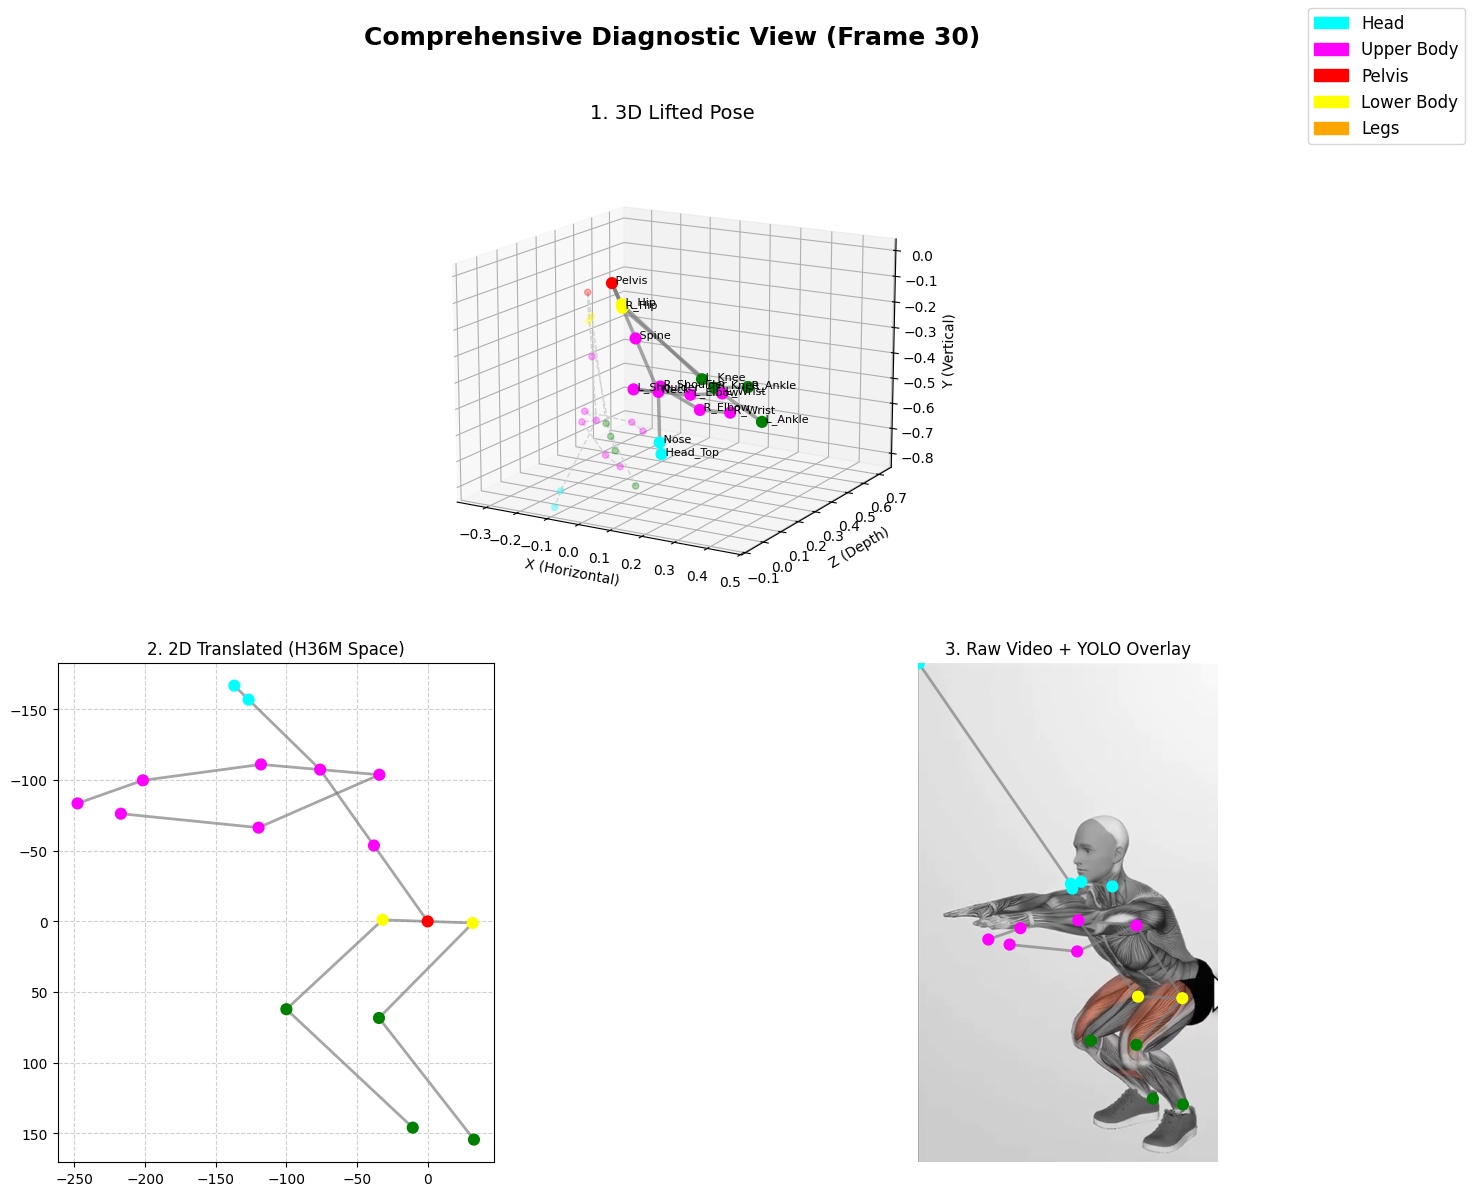

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

# --- 1. CONFIGURATION ---
video_path = "/content/drive/MyDrive/ITCS 4152 5010/Data/incorrect/anatomy.mp4"
standardized_2d_path = "/content/drive/MyDrive/ITCS 4152 5010/outputs/standardized_2d/incorrect__anatomy_keypoints.npy"
glagcn_path = "/content/drive/MyDrive/ITCS 4152 5010/outputs/poses_3d/glagcn/incorrect__anatomy_keypoints.npy"
FRAME_IDX = 30

# --- 2. COLOR CODING & DEFINITIONS ---
JOINT_NAMES = ["Pelvis", "R_Hip", "R_Knee", "R_Ankle", "L_Hip", "L_Knee", "L_Ankle", "Spine", "Neck", "Nose", "Head_Top", "L_Shoulder", "L_Elbow", "L_Wrist", "R_Shoulder", "R_Elbow", "R_Wrist"]
H36M_BONES = [(0, 1), (1, 2), (2, 3), (0, 4), (4, 5), (5, 6), (0, 7), (7, 8), (8, 9), (9, 10), (8, 11), (11, 12), (12, 13), (8, 14), (14, 15), (15, 16)]
COCO_BONES = [(0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), (8, 10), (5, 11), (6, 12), (11, 12), (11, 13), (13, 15), (12, 14), (14, 16)]

# H36M Colors (17 joints)
H36M_COLORS = np.array(['gray'] * 17, dtype=object)
H36M_COLORS[[9, 10]] = 'cyan'                            # Head
H36M_COLORS[[7, 8, 11, 12, 13, 14, 15, 16]] = 'magenta'  # Upper Body
H36M_COLORS[[0]] = 'red'                                 # Pelvis
H36M_COLORS[[1, 4]] = 'yellow'                           # Lower Body (Hips)
H36M_COLORS[[2, 3, 5, 6]] = 'green'                     # Legs (Knees, Ankles)

# COCO (YOLO) Colors (17 joints)
COCO_COLORS = np.array(['gray'] * 17, dtype=object)
COCO_COLORS[[0, 1, 2, 3, 4]] = 'cyan'                    # Head (Nose, Eyes, Ears)
COCO_COLORS[[5, 6, 7, 8, 9, 10]] = 'magenta'             # Upper Body (Shoulders, Arms)
COCO_COLORS[[11, 12]] = 'yellow'                         # Lower Body (Hips)
COCO_COLORS[[13, 14, 15, 16]] = 'green'                 # Legs (Knees, Ankles)
# Note: COCO doesn't have a distinct pelvis joint to color red.

def _3d(ax, sequence_3d, frame_idx):
    kpts = sequence_3d[frame_idx]
    # --- UPDATED AXIS MAPPING ---
    width_x = kpts[:, 0]
    # Height is now naturally positive from the model output
    height_y = kpts[:, 1]
    depth_z = kpts[:, 2]

    # Plot the Main 3D Skeleton
    # In Matplotlib, the 3rd argument (Z) is the vertical axis.
    # We map Height to the vertical axis.
    # ax.scatter(width_x, depth_z, height_y, c=H36M_COLORS, s=60)

    # Scatter with color groups
    ax.scatter(width_x, depth_z, height_y, c=H36M_COLORS, s=60, alpha=1.0, zorder=5)

    for joint1, joint2 in H36M_BONES:
        ax.plot([width_x[joint1], width_x[joint2]],
                [depth_z[joint1], depth_z[joint2]],
                [height_y[joint1], height_y[joint2]], c='gray', linewidth=2.5, alpha=0.7)

    for i, name in enumerate(JOINT_NAMES):
        ax.text(width_x[i], depth_z[i], height_y[i], f" {name}", size=8, color='black')

    # 2D Shadow
    back_wall_depth = np.min(depth_z) - (np.max(depth_z) - np.min(depth_z)) * 0.2
    ax.scatter(width_x, np.full_like(depth_z, back_wall_depth), height_y, c=H36M_COLORS, s=20, alpha=0.3)
    for joint1, joint2 in H36M_BONES:
        ax.plot([width_x[joint1], width_x[joint2]],
                [back_wall_depth, back_wall_depth],
                [height_y[joint1], height_y[joint2]], c='lightgray', linewidth=1, linestyle='--')

    ax.set_xlabel('X (Horizontal)')
    ax.set_ylabel('Z (Depth)')
    ax.set_zlabel('Y (Vertical)')

    max_range = np.array([width_x.max()-width_x.min(), depth_z.max()-depth_z.min(), height_y.max()-height_y.min()]).max() / 2.0
    mid_x, mid_depth, mid_y = (width_x.max()+width_x.min())*0.5, (depth_z.max()+depth_z.min())*0.5, (height_y.max()+height_y.min())*0.5
    margin = max_range * 1.1
    ax.set_xlim(mid_x - margin, mid_x + margin)
    ax.set_ylim(mid_depth - margin, mid_depth + margin)
    ax.set_zlim(mid_y - margin, mid_y + margin)

# --- 3. LOAD DATA ---
glagcn_data = np.load(glagcn_path)
standardized_sequence_2d = np.load(standardized_2d_path)

standardized_sequence_2d_sliced = standardized_sequence_2d[:, :, :2]
h36m_2d_sequence = convert_coco_to_h36m(standardized_sequence_2d_sliced)
kpts_2d_h36m = h36m_2d_sequence[FRAME_IDX]
pelvis = kpts_2d_h36m[0]
kpts_2d_h36m = kpts_2d_h36m - pelvis

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_IDX)
ret, frame = cap.read()
cap.release()
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else np.zeros((720, 1280, 3), dtype=np.uint8)

# We use the standardized_sequence_2d here directly since it contains the raw YOLO X, Y, and Confidence values
kpts_raw_yolo = standardized_sequence_2d[FRAME_IDX]

# --- 4. PLOTTING ---
fig = plt.figure(figsize=(16, 12))
fig.suptitle(f"Comprehensive Diagnostic View (Frame {FRAME_IDX})", fontsize=18, fontweight='bold')

# Panel 1: 3D GLA-GCN Graph (Top Row)
ax1 = fig.add_subplot(2, 2, (1, 2), projection='3d')
plot_diagnostic_3d(ax1, glagcn_data, FRAME_IDX)
ax1.view_init(elev=15, azim=-60)
ax1.set_title("1. 3D Lifted Pose", fontsize=14)

# Panel 2: 2D H36M Translated Skeleton (Bottom Row, Left)
ax2 = fig.add_subplot(2, 2, 3)
ax2.scatter(kpts_2d_h36m[:, 0], kpts_2d_h36m[:, 1], c=H36M_COLORS, s=60, zorder=5)
for joint1, joint2 in H36M_BONES:
    x = [kpts_2d_h36m[joint1, 0], kpts_2d_h36m[joint2, 0]]
    y = [kpts_2d_h36m[joint1, 1], kpts_2d_h36m[joint2, 1]]
    ax2.plot(x, y, c='gray', linewidth=2, alpha=0.7)
ax2.invert_yaxis()
ax2.set_aspect('equal')
ax2.set_title("2. 2D Translated (H36M Space)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

# Panel 3: Raw Video + YOLO Overlay (Bottom Row, Right)
ax3 = fig.add_subplot(2, 2, 4)
ax3.imshow(frame_rgb)
ax3.scatter(kpts_raw_yolo[:, 0], kpts_raw_yolo[:, 1], c=COCO_COLORS, s=60, zorder=5)
for joint1, joint2 in COCO_BONES:
    x_coords = [kpts_raw_yolo[joint1, 0], kpts_raw_yolo[joint2, 0]]
    y_coords = [kpts_raw_yolo[joint1, 1], kpts_raw_yolo[joint2, 1]]
    if kpts_raw_yolo[joint1, 2] > 0.1 and kpts_raw_yolo[joint2, 2] > 0.1:
        ax3.plot(x_coords, y_coords, c='gray', linewidth=2, alpha=0.7)
ax3.set_title("3. Raw Video + YOLO Overlay", fontsize=12)
ax3.axis('off')

# Legend for body parts
handles = [
    mpatches.Patch(color='cyan', label='Head'),
    mpatches.Patch(color='magenta', label='Upper Body'),
    mpatches.Patch(color='red', label='Pelvis'),
    mpatches.Patch(color='yellow', label='Lower Body'),
    mpatches.Patch(color='orange', label='Legs')
]
fig.legend(handles=handles, loc='upper right', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust to fit title and legend
plt.show()
